# History matching a waterflood, with no simulator to install

This tutorial runs the same ESMDA loop as [`tutorial_pipt.ipynb`](../TinyBox/tutorial_pipt),
but its forward model is [MiniRes](https://github.com/patnr/MiniRes) -- a pure-Python,
two-phase (water/oil) TPFA reservoir simulator. There is no binary to install, no licence,
no deck and no scratch folder: `pip install PET[minires]` and the cell below runs.

The case is a 16x16 five-spot: one injector at the centre, four producers in the corners,
all on rate control. The unknown is the log-permeability field (256 values). The
observations are the water cut and oil rate at each producer, at six report points --
made by `make_case.py`, which draws a 'true' field from the prior and runs MiniRes on it
(a twin experiment).

The wrapper is `simulator.minires.MiniRes`; its module docstring documents the
conventions it owns (report points as step indices, the grid ordering, the
Eclipse-style data-type names, and units).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pipt import ESMDA                        # the assimilation scheme
from simulator.minires import MiniRes         # the simulator we want to use
from input_output import read_config          # the config reader
from misc.structures import PETDataFrame
from misc.read_input_csv import DataReader

## The config

`[simulator.model]` is passed to `minires.ResSim` as it stands -- the grid, the porosity
and the wells -- less the permeability, which is what the ensemble state supplies, one
field per member.

In [2]:
!cat CONFIG_ESMDA.toml

[ensemble]
    ne    = 100
    state = "permx"   # log-permeability, one value per grid cell

    [ensemble.prior_permx]
        vario = "sph"
        mean  = "priormean.npz"
        var   = 1.0
        range = 5.0
        aniso = 1.0
        angle = 0.0
        grid  = [16, 16, 1]

[dataassim]
    savefolder = "Results"
    scheme     = "esmda"
    analysis   = "approx"
    energy     = 99.0
    obsname    = "steps"
    data       = "data.csv"
    datavar    = "var.csv"
    savedata   = ["ensemble_misfit"]

    # ESMDA settings
    [dataassim.mda]
        tot_assim_steps = 3
        inflation_param = [3, 3, 3]

[simulator]
    # The report points are *step indices*: MiniRes takes a uniform dt.
    dt          = 0.025
    reporttype  = "steps"
    reportpoint = [2, 4, 6, 8, 10, 12]
    parallel    = 1
    datatype    = [
        "WWCT:PRD1", "WWCT:PRD2", "WWCT:PRD3", "WWCT:PRD4",
        "WOPR:PRD1", "WOPR:PRD2", "WOPR:PRD3", "WOPR:PRD4",
    ]

    # Passed to minires.ResSim as it sta

In [3]:
kwda, kwsim, kwens = read_config.read('CONFIG_ESMDA.toml')
sim = MiniRes(kwsim)
sim.model

ResSim(
              Lx: 1.0
              Ly: 1.0
              Nx: 16
              Ny: 16
            name: 'Unnamed'
          cdarcy: 1.0
           fluid: Fluid(
                      vw: 1.0
                      vo: 1.0
                     swc: 0.0
                     sor: 0.0
                      nw: 2.0
                      no: 2.0
                    krw0: 1.0
                    kro0: 1.0
                  )
              ct: 0.0
  cached_precond: True
               K: array([[[1., 1., ..., 1., 1.],
                          [1., 1., ..., 1., 1.],
                          ...,
                          [1., 1., ..., 1., 1.],
                          [1., 1., ..., 1., 1.]],

                         [[1., 1., ..., 1., 1.],
                          [1., 1., ..., 1., 1.],
                          ...,
                          [1., 1., ..., 1., 1.],
                          [1., 1., ..., 1., 1.]]], shape=(2, 16, 16))
             por: array([[0.2, 0.2, ..., 0.2, 0.2

## The truth

MiniRes brings its own plotting, so the field and its wells can be shown without
any extra tooling. This is the field the observations were made on; the ensemble
does not know it.

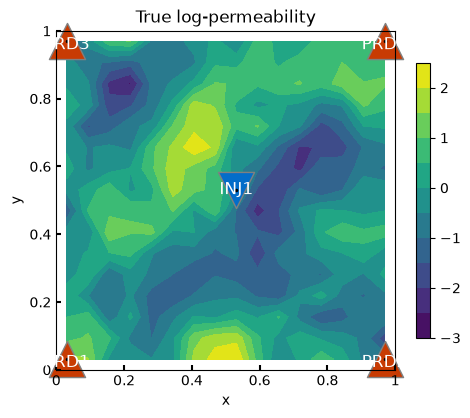

In [4]:
truth = np.load('truth.npz')['permx']

fig, ax = plt.subplots(figsize=(5, 4.2))
sim.model.plt_field(ax, truth, wells=True, finalize=False)
ax.set_title('True log-permeability')
fig.tight_layout()


## Run the assimilation

Exactly as in the other tutorials -- the simulator is the only thing that differs.
100 members, 3 ESMDA steps: a few seconds.

In [5]:
np.random.seed(10)
res = ESMDA.assimilate(kwda, kwens, MiniRes(kwsim))
print(f'data misfit: {res.prior_data_misfit:.1f} -> {res.data_misfit:.1f}')

2026-09-21│15:44:05 :  =========== Running Data Assimilation - ESMDA ===========


/Users/para/D/DPhil/PET-minires/src/misc/structures/structures.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(filepath, **kwargs)
/Users/para/D/DPhil/PET-minires/src/misc/structures/structures.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(filepath, **kwargs)



2026-09-21│15:44:08 : 


2026-09-21│15:44:08 :  ┌─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐


2026-09-21│15:44:08 :  │  Iteration  │   Status    │ Data Misfit │ Change (%)  │      α      │


...

2026-09-21│15:44:14 : 


2026-09-21│15:44:14 : Maximum iterations reached without convergence.


2026-09-21│15:44:14 :  
 Stopped without convergence. Obj. function reduced from 691.6 to 108.5


2026-09-21│15:44:14 :  Assimilation finished after 3 iteration(s): Maximum number of iterations reached


data misfit: 691.6 -> 108.5


## The misfit, per iteration

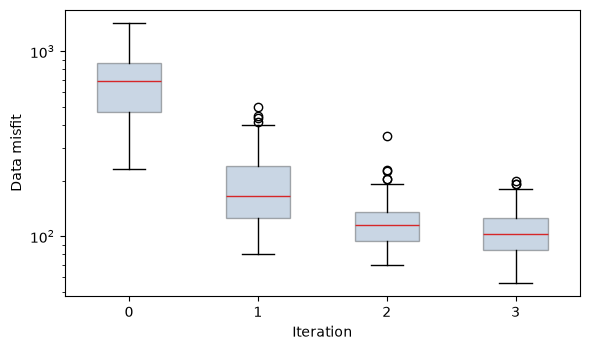

In [6]:
from pathlib import Path

misfit, it = [], 0
while (file := Path(f'Results/assimilation_result_{it}.npz')).exists():
    misfit.append(np.load(file)['ensemble_misfit'])
    it += 1

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.boxplot(misfit, positions=range(len(misfit)), widths=0.5, patch_artist=True,
           boxprops=dict(facecolor='#4C78A8', alpha=0.3), medianprops=dict(color='#D62728'))
ax.set(xlabel='Iteration', ylabel='Data misfit', yscale='log')
fig.tight_layout()


## The fields

The ensemble mean before and after. With 100 members, 48 data and 256 unknowns and no
localization, the posterior mean picks up the large-scale flow paths between the injector
and the producers, not the fine structure.

corr(mean, truth):  prior 0.169  ->  posterior 0.313


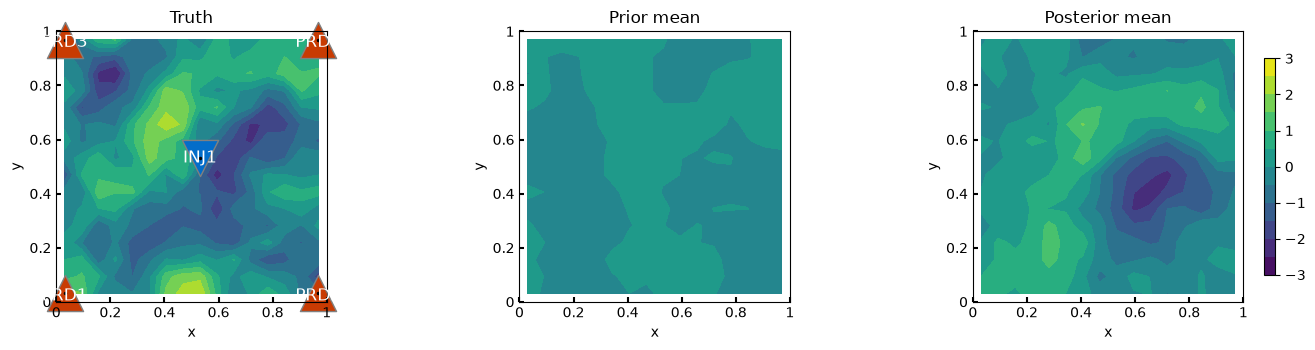

In [7]:
prior = np.load('prior_ensemble.npz')['permx']
post = np.asarray(res.x)

levels = np.linspace(-3, 3, 13)   # one colour scale for all three panels
fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
for i, (ax, field, title) in enumerate(zip(axs, [truth, prior.mean(1), post.mean(1)],
                                           ['Truth', 'Prior mean', 'Posterior mean'])):
    sim.model.plt_field(ax, field, levels=levels, wells=(i == 0), colorbar=(i == 2), finalize=False)
    ax.set_title(title)
fig.tight_layout()

print('corr(mean, truth):  prior %.3f  ->  posterior %.3f'
      % (np.corrcoef(prior.mean(1), truth)[0, 1], np.corrcoef(post.mean(1), truth)[0, 1]))

## The data match

The prior and posterior forecasts that the run saved, against the observations.

/Users/para/D/DPhil/PET-minires/src/misc/structures/structures.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(filepath, **kwargs)
/Users/para/D/DPhil/PET-minires/src/misc/structures/structures.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(filepath, **kwargs)


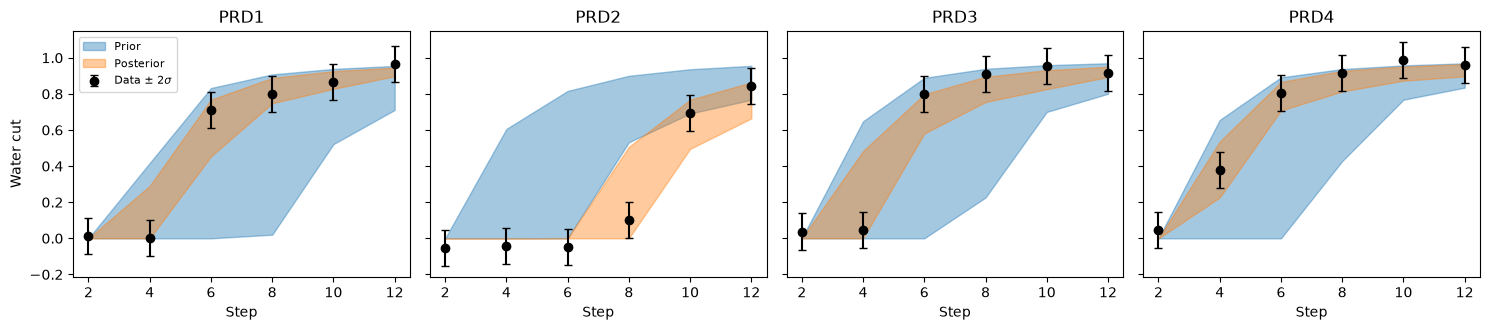

In [8]:
reader = DataReader({'data': 'data.csv', 'datavar': 'var.csv'})
data = reader.get_data()
std = np.sqrt(reader.get_variance(data))

forecasts = {}
for label, file in [('Prior', 'prior_forecast.pkl'), ('Posterior', 'posterior_forecast.pkl')]:
    frame = PETDataFrame.from_pickle(f'Results/{file}')
    frame.is_ensemble = True
    forecasts[label] = frame

fig, axs = plt.subplots(1, 4, figsize=(15, 3.4), sharex=True, sharey=True)
for ax, well in zip(axs, ['PRD1', 'PRD2', 'PRD3', 'PRD4']):
    key = f'WWCT:{well}'
    for (label, frame), color in zip(forecasts.items(), ['tab:blue', 'tab:orange']):
        ens = np.asarray(frame[key].tolist())
        ax.fill_between(frame.index, ens.min(1), ens.max(1), color=color, alpha=0.4, label=label)
    ax.errorbar(data.index, data[key], yerr=2 * std[key], fmt='o', color='k', capsize=3,
                label=r'Data $\pm$ 2$\sigma$')
    ax.set(title=well, xlabel='Step')
axs[0].set_ylabel('Water cut')
axs[0].legend(loc='upper left', fontsize=8)
fig.tight_layout()


## What else this simulator can do here

- **Adjoints.** Set `compute_adjoints = true` in `[simulator]` and the wrapper returns each
  datum's sensitivity to the state as well, so the analyses take the adjoint-based path
  instead of the ensemble covariance. MiniRes differentiates its own time stepper
  (`minires.tlm`), one backward sweep per datum, each about the cost of one simulation.
  Covered for `WWCT`/`WWPR`/`WOPR` at rate-controlled wells.
- **Multilevel.** `[[simulator.levels]]` entries override the config per fidelity level;
  `setup_fwd_run(level=...)` selects one, e.g. a coarser `dt`.
- **Wells** may be BHP-controlled (`bhp` in place of `rate`), multi-completion (`path`),
  or aquifer contacts; inactive cells (`active`) cut the grid to an outline.
- **Units**: set `cdarcy = 0.008527` in `[simulator.model]` to pose the case in metric
  (m, day, bar, mD, cP), as Eclipse does. Rates are then areal (per unit thickness).